In [1]:
# @title Running in Colab

from IPython.display import HTML, Javascript, display

display(
    HTML(
        """<a href="https://colab.research.google.com/github/evan-lloyd/mechinterp-experiments/blob/main/tiny_stories_sae/feature_interaction_demo.ipynb" target="_blank" id="colab-button">
            Run this notebook in Google Colab
        </a>"""
    )
)
display(
    Javascript("""
        setTimeout(() => {
            if(typeof google.colab != "undefined") {
                document.querySelector("#colab-button").remove()
            }
        }, 0);
        """)
)

<IPython.core.display.Javascript object>

# Initialize notebook environment

In [2]:
import os

# If we're running in Colab, we need to clone the non-notebook source from git.
if os.getenv("COLAB_RELEASE_TAG") and not os.path.isdir(
    "/content/mechinterp-experiments"
):
    ip = get_ipython()  #  pyright: ignore[reportUndefinedVariable]
    ip.run_cell_magic(
        "bash",
        "",
        """
    git clone --filter=blob:none --no-checkout https://github.com/evan-lloyd/mechinterp-experiments.git
    cd mechinterp-experiments
    git sparse-checkout init --no-cone
    echo "/tiny_stories_sae" > .git/info/sparse-checkout
    git checkout
  """,
    )
    ip.run_line_magic("cd", "mechinterp-experiments/tiny_stories_sae")
else:
    print("Already cloned source, or not running in Colab.")

# Nice for dev, but not needed for Colab.
try:
    # This uses a library called jurigged to hot-reload code when it is changed.
    # For reasons I've never been able to figure out, the IPython %autoreload magic
    # completely fails to work with the kind of structure I use in this notebook.
    import tiny_stories_sae._autoreload
except Exception:
    pass

Already cloned source, or not running in Colab.


In [3]:
import torch
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer

# Tweak TRAINING_BATCH_SIZE for your hardware if necessary
if torch.cuda.is_available():
    TRAINING_DEVICE = "cuda:0"
    TRAINING_BATCH_SIZE = 16
    E2E_BATCH_SIZE = 4
elif torch.mps.is_available():
    TRAINING_DEVICE = "mps:0"
    TRAINING_BATCH_SIZE = 8
    E2E_BATCH_SIZE = 2
else:
    TRAINING_DEVICE = "cpu"
    TRAINING_BATCH_SIZE = 8
    E2E_BATCH_SIZE = 2

tokenizer = AutoTokenizer.from_pretrained("EleutherAI/gpt-neo-125M")
training_dataset = load_dataset("roneneldan/TinyStories", split="train", streaming=True)
validation_dataset = load_dataset(
    "roneneldan/TinyStories", split="validation", streaming=True
)
model = AutoModelForCausalLM.from_pretrained("roneneldan/TinyStories-33M").to(
    TRAINING_DEVICE
)

print(model)

GPTNeoForCausalLM(
  (transformer): GPTNeoModel(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(2048, 768)
    (drop): Dropout(p=0.0, inplace=False)
    (h): ModuleList(
      (0-3): 4 x GPTNeoBlock(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPTNeoAttention(
          (attention): GPTNeoSelfAttention(
            (attn_dropout): Dropout(p=0.0, inplace=False)
            (resid_dropout): Dropout(p=0.0, inplace=False)
            (k_proj): Linear(in_features=768, out_features=768, bias=False)
            (v_proj): Linear(in_features=768, out_features=768, bias=False)
            (q_proj): Linear(in_features=768, out_features=768, bias=False)
            (out_proj): Linear(in_features=768, out_features=768, bias=True)
          )
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPTNeoMLP(
          (c_fc): Linear(in_features=768, out_features=3072, bias=True)
          (c_proj): Linear(in_feat

In [ ]:
# Caches model activations to these directories; modify if necessary, or set to None to disable.
# These take up ~16GB and ~1.5GB respectively, but will save a fair bit of time when running
# the notebook, since they can be re-used across all methods we're comparing.
# TRAINING_CACHE_DIR = None
# VALIDATION_CACHE_DIR = None
TRAINING_CACHE_DIR = ".training_cache"
VALIDATION_CACHE_DIR = ".validation_cache"
NUM_TRAINING_TOKENS = int(1e6)
EVAL_INTERVAL = int(1e5)
NUM_VALIDATION_TOKENS = int(1e5)
D_MODEL = model.config.hidden_size
D_SAE = D_MODEL * 4
TOPK = 100
TOKENIZER_BATCH_SIZE = 128
FINETUNE_FRACTION = 0.1
# Note this will use up ~1.8GB of space, set to False if you want to skip
SAVE_FINAL_RESULTS = True

# Train SAEs

In [ ]:
from itertools import product

import numpy as np

from tiny_stories_sae.sae import (
    SAE,
    DecoderConfig,
    EncoderConfig,
    InteractionEncoderConfig,
    ReluActivationFunctionConfig,
    SAEConfig,
    TopKActivationFunctionConfig,
)
from tiny_stories_sae.training import TrainingConfig, TrainingMethod, fine_tune, train
from tiny_stories_sae.validation import run_validations


def SAE_SPECS():
    return product(TrainingMethod, (False, True))


empty_saes = {
    (method, use_interaction): {
        layer: SAE(
            SAEConfig(
                d_model=D_MODEL,
                d_sae=D_SAE,
                device=TRAINING_DEVICE,
                encoder=EncoderConfig(
                    d_model=D_MODEL,
                    d_sae=D_SAE,
                    device=TRAINING_DEVICE,
                    activation_function=TopKActivationFunctionConfig(k=TOPK),
                )
                if not use_interaction
                else InteractionEncoderConfig(
                    d_model=D_MODEL,
                    d_sae=D_SAE,
                    device=TRAINING_DEVICE,
                    activation_function=TopKActivationFunctionConfig(k=TOPK),
                    n_interaction_iterations=1,
                ),
                decoder=DecoderConfig(
                    d_model=D_MODEL,
                    d_sae=D_SAE,
                    device=TRAINING_DEVICE,
                ),
            )
        )
        for layer in range(model.config.num_layers)
    }
    for method, use_interaction in SAE_SPECS()
}


def linear_decay(frac_trained: float):
    return 1.0 - frac_trained


training_config = {
    (method, use_interaction): TrainingConfig(
        tokenizer_batch_size=TOKENIZER_BATCH_SIZE,
        training_batch_size=TRAINING_BATCH_SIZE,
        e2e_batch_size=E2E_BATCH_SIZE,
        num_train_tokens=NUM_TRAINING_TOKENS,
        eval_interval=EVAL_INTERVAL,
        train_layers=list(range(model.config.num_layers)),
        lr=1e-3,
        interaction_lr=1e-3,
        finetune_lr_schedule=linear_decay,  # per Karvonen (2025)
        use_downstream_saes=method
        in (TrainingMethod.next_layer, TrainingMethod.next_layer_finetuned),
        downstream_reconstruction_weight=1.0,
        reconstruction_weight=1.0,
        balance_reconstruction_losses=True,
        method=method,
        finetune_fraction=FINETUNE_FRACTION
        if method in (TrainingMethod.finetuned, TrainingMethod.next_layer_finetuned)
        else None,
    )
    for method, use_interaction in SAE_SPECS()
}

training_results = {}
validation_results = {}

In [6]:
import os

from tiny_stories_sae.activation_cache import build_cache

if TRAINING_CACHE_DIR and (
    not os.path.exists(TRAINING_CACHE_DIR) or not os.listdir(TRAINING_CACHE_DIR)
):
    build_cache(
        TRAINING_CACHE_DIR,
        model,
        tokenizer,
        training_dataset,
        tokenizer_batch_size=TOKENIZER_BATCH_SIZE,
        inference_batch_size=TRAINING_BATCH_SIZE,
        num_tokens=NUM_TRAINING_TOKENS,
    )

if VALIDATION_CACHE_DIR and (
    not os.path.exists(VALIDATION_CACHE_DIR) or not os.listdir(VALIDATION_CACHE_DIR)
):
    build_cache(
        VALIDATION_CACHE_DIR,
        model,
        tokenizer,
        validation_dataset,
        tokenizer_batch_size=TOKENIZER_BATCH_SIZE,
        inference_batch_size=TRAINING_BATCH_SIZE,
        num_tokens=NUM_VALIDATION_TOKENS,
    )

In [7]:
for spec in SAE_SPECS():
    # We finetune these from checkpoints of other methods
    if spec[0] in (TrainingMethod.finetuned, TrainingMethod.next_layer_finetuned):
        continue
    print(f"Training {spec[0].value}, use_interaction={spec[1]}")
    training_results[spec] = train(
        model,
        tokenizer,
        empty_saes[spec],
        training_dataset,
        training_config[spec],
        cache_dir=TRAINING_CACHE_DIR,
        checkpoints_at=[int((1.0 - FINETUNE_FRACTION) * NUM_TRAINING_TOKENS)]
        if spec[0] in (TrainingMethod.standard, TrainingMethod.next_layer)
        else None,
    )
    validation_results[spec] = run_validations(
        model,
        tokenizer,
        training_results[spec].final_saes,
        validation_dataset,
        num_tokens=NUM_VALIDATION_TOKENS,
        tokenizer_batch_size=training_config[spec].tokenizer_batch_size,
        inference_batch_size=training_config[spec].training_batch_size,
        cache_dir=VALIDATION_CACHE_DIR,
    )
    print(
        f"mean rre={ {k: np.mean(v.rre).item() for k, v in validation_results[spec].layer_results.items() if v.rre is not None} })"
    )
    print(
        f"mean kl={ {k: np.mean(v.kl).item() for k, v in validation_results[spec].layer_results.items() if v.kl is not None} })"
    )

Training Standard, use_interaction=False


Layer 3

  0%|          | 0/1000000 [00:00<?, ?it/s]

Layer 2

  0%|          | 0/1000000 [00:00<?, ?it/s]

...

  0%|          | 0/1000000 [00:00<?, ?it/s]

Layer 0

  0%|          | 0/1000000 [00:00<?, ?it/s]

Running SAE evals:   0%|          | 0/100000 [00:00<?, ?it/s]

mean rre={0: 0.4742276966571808, 1: 0.5287720561027527, 2: 0.658826470375061, 3: 0.9013938307762146})
mean kl={4: 1.6985437870025635})


In [8]:
for spec in SAE_SPECS():
    if spec[0] not in (TrainingMethod.finetuned, TrainingMethod.next_layer_finetuned):
        continue
    print(f"Training {spec[0].value}, use_interaction={spec[1]}")
    training_results[spec] = fine_tune(
        model,
        tokenizer,
        training_results[
            (
                TrainingMethod.standard
                if spec[0] == TrainingMethod.finetuned
                else TrainingMethod.next_layer,
                spec[1],
            )
        ],
        0,
        training_dataset,
        training_config[spec],
        cache_dir=TRAINING_CACHE_DIR,
    )
    validation_results[spec] = run_validations(
        model,
        tokenizer,
        training_results[spec].final_saes,
        validation_dataset,
        num_tokens=NUM_VALIDATION_TOKENS,
        tokenizer_batch_size=training_config[spec].tokenizer_batch_size,
        inference_batch_size=training_config[spec].training_batch_size,
        cache_dir=VALIDATION_CACHE_DIR,
    )
    print(
        f"mean rre={ {k: np.mean(v.rre).item() for k, v in validation_results[spec].layer_results.items() if v.rre is not None} })"
    )
    print(
        f"mean kl={ {k: np.mean(v.kl).item() for k, v in validation_results[spec].layer_results.items() if v.kl is not None} })"
    )


Training KL Fine-tuning, use_interaction=False


Layer 3

  0%|          | 0/97873 [00:00<?, ?it/s]

Layer 2

  0%|          | 0/97873 [00:00<?, ?it/s]

...

  0%|          | 0/97873 [00:00<?, ?it/s]

Layer 0

  0%|          | 0/97873 [00:00<?, ?it/s]

Running SAE evals:   0%|          | 0/100000 [00:00<?, ?it/s]

mean rre={0: 0.2852349579334259, 1: 0.40222424268722534, 2: 0.5314192771911621, 3: 0.9246975779533386})
mean kl={4: 1.508509635925293})


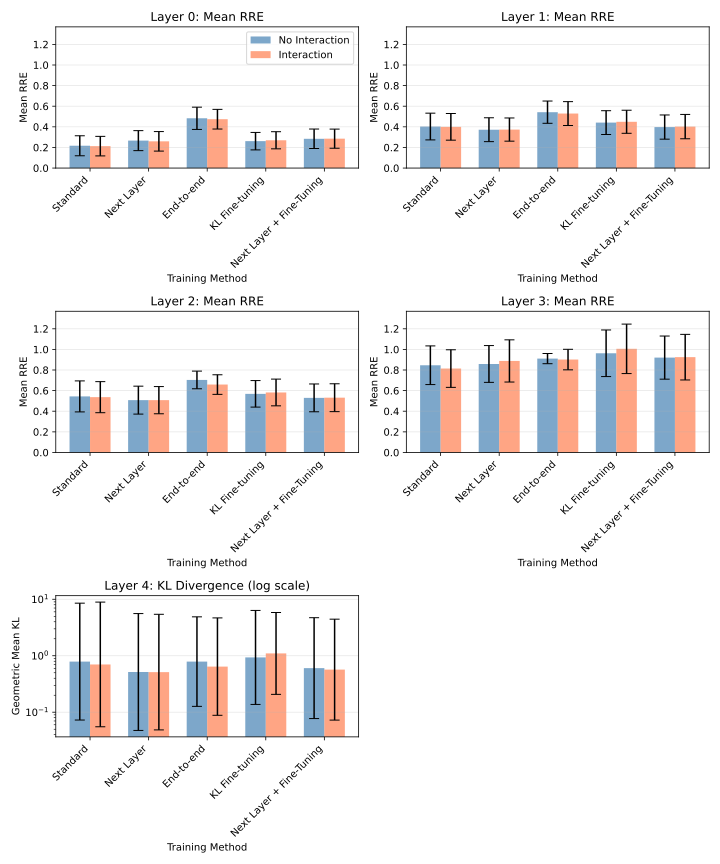

In [9]:
import matplotlib.pyplot as plt
import numpy as np

from tiny_stories_sae.ops import current_plot_to_svg

num_plots = model.config.num_layers + 1
num_cols = 2
num_rows = (num_plots + num_cols - 1) // num_cols
fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
axes = axes.flatten()

plot_idx = 0

# Group specs by method
methods = []
seen_methods = set()
for spec in validation_results:
    if spec[0] not in seen_methods:
        methods.append(spec[0])
        seen_methods.add(spec[0])

method_labels = [m.value for m in methods]
x = np.arange(len(methods))
bar_width = 0.35

colors = {'no_interaction': 'steelblue', 'interaction': 'coral'}

# Plot RRE bar charts for each layer
# First pass: compute global max for RRE across all layers
rre_max = 0
for layer in range(model.config.num_layers):
    for method in methods:
        for use_interaction in [False, True]:
            spec = (method, use_interaction)
            if spec in validation_results and layer in validation_results[spec].layer_results:
                rre_values = validation_results[spec].layer_results[layer].rre
                if rre_values is not None and len(rre_values) > 0:
                    rre_max = max(rre_max, np.mean(rre_values) + np.std(rre_values))

for layer in range(model.config.num_layers):
    ax = axes[plot_idx]
    means_no_int = []
    stds_no_int = []
    means_int = []
    stds_int = []
    
    for method in methods:
        # No interaction
        spec_no_int = (method, False)
        if spec_no_int in validation_results and layer in validation_results[spec_no_int].layer_results:
            rre_values = validation_results[spec_no_int].layer_results[layer].rre
            if rre_values is not None and len(rre_values) > 0:
                means_no_int.append(np.mean(rre_values))
                stds_no_int.append(np.std(rre_values))
            else:
                means_no_int.append(0)
                stds_no_int.append(0)
        else:
            means_no_int.append(0)
            stds_no_int.append(0)
        
        # With interaction
        spec_int = (method, True)
        if spec_int in validation_results and layer in validation_results[spec_int].layer_results:
            rre_values = validation_results[spec_int].layer_results[layer].rre
            if rre_values is not None and len(rre_values) > 0:
                means_int.append(np.mean(rre_values))
                stds_int.append(np.std(rre_values))
            else:
                means_int.append(0)
                stds_int.append(0)
        else:
            means_int.append(0)
            stds_int.append(0)
    
    ax.bar(x - bar_width/2, means_no_int, bar_width, yerr=stds_no_int, capsize=5, alpha=0.7, 
           color=colors['no_interaction'], label='No Interaction')
    ax.bar(x + bar_width/2, means_int, bar_width, yerr=stds_int, capsize=5, alpha=0.7,
           color=colors['interaction'], label='Interaction')
    ax.set_xlabel("Training Method")
    ax.set_ylabel("Mean RRE")
    ax.set_title(f"Layer {layer}: Mean RRE")
    ax.set_xticks(x)
    ax.set_xticklabels(method_labels, rotation=45, ha='right')
    ax.set_ylim(0, rre_max * 1.1)
    ax.grid(True, alpha=0.3, axis='y')
    if plot_idx == 0:
        ax.legend()
    plot_idx += 1

# Plot KL bar charts in log-space for each layer that has it
for layer in [model.config.num_layers]:
    ax = axes[plot_idx]
    gmeans_no_int = []
    gstd_lower_no_int = []
    gstd_upper_no_int = []
    gmeans_int = []
    gstd_lower_int = []
    gstd_upper_int = []
    
    for method in methods:
        # No interaction
        spec_no_int = (method, False)
        if spec_no_int in validation_results and layer in validation_results[spec_no_int].layer_results:
            kl_values = validation_results[spec_no_int].layer_results[layer].kl
            if kl_values is not None and len(kl_values) > 0:
                kl_positive = kl_values[kl_values > 0]
                if len(kl_positive) > 0:
                    log_kl = np.log(kl_positive)
                    log_mean = np.mean(log_kl)
                    log_std = np.std(log_kl)
                    gm = np.exp(log_mean)
                    gmeans_no_int.append(gm)
                    gsd = np.exp(log_std)
                    gstd_lower_no_int.append(gm - gm / gsd)
                    gstd_upper_no_int.append(gm * gsd - gm)
                else:
                    gmeans_no_int.append(0)
                    gstd_lower_no_int.append(0)
                    gstd_upper_no_int.append(0)
            else:
                gmeans_no_int.append(0)
                gstd_lower_no_int.append(0)
                gstd_upper_no_int.append(0)
        else:
            gmeans_no_int.append(0)
            gstd_lower_no_int.append(0)
            gstd_upper_no_int.append(0)
        
        # With interaction
        spec_int = (method, True)
        if spec_int in validation_results and layer in validation_results[spec_int].layer_results:
            kl_values = validation_results[spec_int].layer_results[layer].kl
            if kl_values is not None and len(kl_values) > 0:
                kl_positive = kl_values[kl_values > 0]
                if len(kl_positive) > 0:
                    log_kl = np.log(kl_positive)
                    log_mean = np.mean(log_kl)
                    log_std = np.std(log_kl)
                    gm = np.exp(log_mean)
                    gmeans_int.append(gm)
                    gsd = np.exp(log_std)
                    gstd_lower_int.append(gm - gm / gsd)
                    gstd_upper_int.append(gm * gsd - gm)
                else:
                    gmeans_int.append(0)
                    gstd_lower_int.append(0)
                    gstd_upper_int.append(0)
            else:
                gmeans_int.append(0)
                gstd_lower_int.append(0)
                gstd_upper_int.append(0)
        else:
            gmeans_int.append(0)
            gstd_lower_int.append(0)
            gstd_upper_int.append(0)
    
    ax.bar(x - bar_width/2, gmeans_no_int, bar_width, yerr=[gstd_lower_no_int, gstd_upper_no_int], 
           capsize=5, alpha=0.7, color=colors['no_interaction'], label='No Interaction')
    ax.bar(x + bar_width/2, gmeans_int, bar_width, yerr=[gstd_lower_int, gstd_upper_int],
           capsize=5, alpha=0.7, color=colors['interaction'], label='Interaction')
    ax.set_yscale('log')
    ax.set_xlabel("Training Method")
    ax.set_ylabel("Geometric Mean KL")
    ax.set_title(f"Layer {layer}: KL Divergence (log scale)")
    ax.set_xticks(x)
    ax.set_xticklabels(method_labels, rotation=45, ha='right')
    ax.grid(True, alpha=0.3, axis='y')
    # ax.legend()
    plot_idx += 1

# Hide any unused axes
for i in range(plot_idx, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
current_plot_to_svg()

In [10]:
from tiny_stories_sae.ops import save_training_result

if SAVE_FINAL_RESULTS:
    for spec in SAE_SPECS():
        save_training_result(
            training_results[spec],
            f".checkpoints/feature_interaction_demo/{spec[0].name}{'_interaction' if spec[1] else ''}",
        )